In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import multiprocessing

BASE_DIR = "/Users/nikitagolikov/Documents/Projects/Python/Diploma/PKLot"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Проверка устройства. Для Mac (Apple Silicon) используем mps, иначе cpu
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Вычисления будут производиться на: {device}")

Вычисления будут производиться на: mps


In [3]:
class YoloCropDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.patches_info = []

        # Improved path handling
        self.images_dir = os.path.join(root_dir, "images") if os.path.isdir(os.path.join(root_dir, "images")) else root_dir
        self.labels_dir = os.path.join(root_dir, "labels") if os.path.isdir(os.path.join(root_dir, "labels")) else root_dir

        # Get list of image files first
        valid_extensions = ('.jpg', '.png', '.jpeg')
        image_files = [f for f in os.listdir(self.images_dir) if f.lower().endswith(valid_extensions)]

        print(f"Indexing labels from {root_dir}...")
        for img_name in image_files:
            label_name = os.path.splitext(img_name)[0] + ".txt"
            label_path = os.path.join(self.labels_dir, label_name)

            if os.path.exists(label_path):
                # We only open the small text file, which is much faster than images
                with open(label_path, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            # Store metadata only
                            self.patches_info.append({
                                'img_name': img_name,
                                'cls_id': int(parts[0]),
                                'coords': list(map(float, parts[1:]))
                            })

        print(f"Found {len(self.patches_info)} patches.")

    def __len__(self):
        return len(self.patches_info)

    def __getitem__(self, idx):
        info = self.patches_info[idx]
        img_path = os.path.join(self.images_dir, info['img_name'])

        # Read image ONLY when requested by the DataLoader
        image = cv2.imread(img_path)
        if image is None:
            return torch.zeros((3, 128, 128)), info['cls_id']

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_h, img_w, _ = image.shape

        x, y, w, h = info['coords']

        # Relative to absolute
        left = int(max(0, (x - w / 2) * img_w))
        upper = int(max(0, (y - h / 2) * img_h))
        right = int(min(img_w, (x + w / 2) * img_w))
        lower = int(min(img_h, (y + h / 2) * img_h))

        patch = image[upper:lower, left:right]

        if patch.size == 0:
            patch = np.zeros((128, 128, 3), dtype=np.uint8)

        patch_pil = Image.fromarray(patch)

        if self.transform:
            patch_pil = self.transform(patch_pil)

        return patch_pil, info['cls_id']

In [4]:
from dataset import YoloCropDataset
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = YoloCropDataset(TRAIN_DIR, transform=transform)
val_dataset = YoloCropDataset(VAL_DIR, transform=transform)
test_dataset = YoloCropDataset(TEST_DIR, transform=transform)

print(f"Количество вырезанных патчей (train): {len(train_dataset)}")
print(f"Количество вырезанных патчей (val): {len(val_dataset)}")
print(f"Количество вырезанных патчей (test): {len(test_dataset)}")

# Если здесь нули, дальше запускать нет смысла — нужно смотреть структуру папок
num_cpus = multiprocessing.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2 # This will work now
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


Количество вырезанных патчей (train): 497856
Количество вырезанных патчей (val): 143316
Количество вырезанных патчей (test): 70684


In [5]:
class ParkingCNN(nn.Module):
    def __init__(self):
        super(ParkingCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Вход 128x128. После 3 слоев пулинга (128 -> 64 -> 32 -> 16) размер станет 16x16
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2) # 2 класса: Свободно (0), Занято (1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 16 * 16) # Расплющиваем
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ParkingCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
# Cell 5 — Тренировочный цикл
import time

# Now you can use num_workers > 0 safely!

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        # Валидация
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        end_time = time.time()

        print(f"Эпоха [{epoch+1}/{epochs}] | "
              f"Loss: {epoch_loss:.4f} | "
              f"Train Acc: {epoch_acc:.2f}% | "
              f"Val Acc: {val_acc:.2f}% | "
              f"Время: {end_time - start_time:.1f}с")

# Запуск
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=4)

Эпоха [1/4] | Loss: 0.0690 | Train Acc: 97.74% | Val Acc: 99.19% | Время: 1550.7с
Эпоха [2/4] | Loss: 0.0272 | Train Acc: 99.21% | Val Acc: 99.54% | Время: 1359.2с
Эпоха [3/4] | Loss: 0.0197 | Train Acc: 99.47% | Val Acc: 99.72% | Время: 1336.4с
Эпоха [4/4] | Loss: 0.0168 | Train Acc: 99.56% | Val Acc: 99.74% | Время: 1333.5с


Обработка файла: 2013-04-15_07_05_01_jpg.rf.061112e4e25c7bf97b16897372240067.jpg


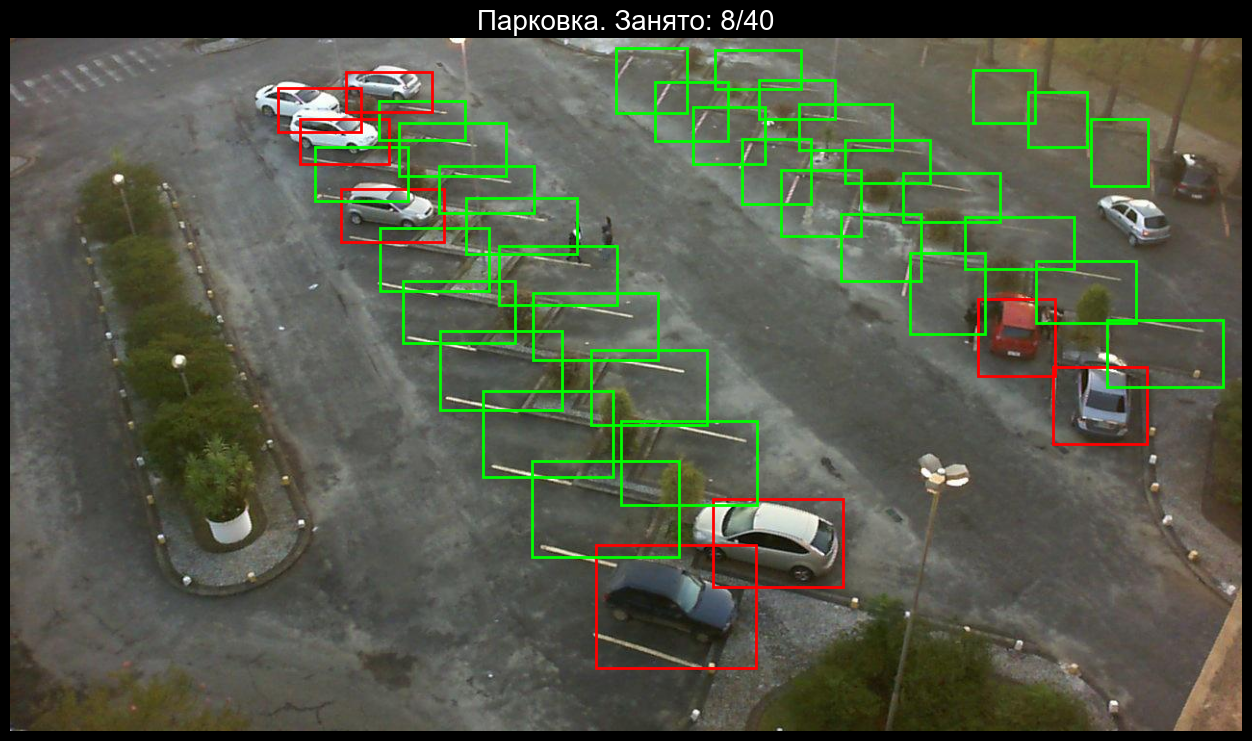

In [7]:
def count_cars_and_visualize(image_path, label_path, model, transform, device):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w, _ = image.shape

    total_spots = 0
    occupied_spots = 0

    fig, ax = plt.subplots(1, figsize=(16, 9))
    ax.imshow(image)

    model.eval()

    with open(label_path, "r") as f:
        lines = f.readlines()
        total_spots = len(lines)

        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                _, x, y, w, h = map(float, parts)

                abs_x, abs_y = x * img_w, y * img_h
                abs_w, abs_h = w * img_w, h * img_h

                left = int(max(0, abs_x - abs_w / 2))
                upper = int(max(0, abs_y - abs_h / 2))
                right = int(min(img_w, abs_x + abs_w / 2))
                lower = int(min(img_h, abs_y + abs_h / 2))

                # Кроп патча для сети
                patch = image[upper:lower, left:right]
                if patch.size == 0:
                    continue

                patch_pil = Image.fromarray(patch)
                input_tensor = transform(patch_pil).unsqueeze(0).to(device)

                with torch.no_grad():
                    output = model(input_tensor)
                    _, predicted = torch.max(output, 1)
                    is_occupied = predicted.item() == 1

                if is_occupied:
                    occupied_spots += 1
                    color = 'red' # Красный - занято
                else:
                    color = 'lime' # Зеленый - свободно

                # Рисуем рамку на графике
                rect = patches.Rectangle(
                    (left, upper), abs_w, abs_h,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)

    plt.title(f"Парковка. Занято: {occupied_spots}/{total_spots}", fontsize=20)
    plt.axis('off')
    plt.show()

# Тестируем на случайном фото из TEST_DIR
test_img_dir = os.path.join(TEST_DIR, "images") if os.path.isdir(os.path.join(TEST_DIR, "images")) else TEST_DIR
test_lbl_dir = os.path.join(TEST_DIR, "labels") if os.path.isdir(os.path.join(TEST_DIR, "labels")) else TEST_DIR

# Берем первый попавшийся jpg файл
for file_name in os.listdir(test_img_dir):
    if file_name.endswith('.jpg'):
        test_img_path = os.path.join(test_img_dir, file_name)
        test_lbl_path = os.path.join(test_lbl_dir, file_name.replace('.jpg', '.txt'))

        if os.path.exists(test_lbl_path):
            print(f"Обработка файла: {file_name}")
            count_cars_and_visualize(test_img_path, test_lbl_path, model, transform, device)
            break

In [8]:
torch.save(model.state_dict(), 'parking_cnn_weights.pth')